# Sentiment-Driven Analysis of Cryptocurrency Trader Performance and Segmentation

This project analyzes how cryptocurrency trader behavior and profitability are influenced by market sentiment (Fear & Greed Index), and reveals which types of traders (high vs. low size, consistent vs. inconsistent, frequent vs. infrequent) perform best under different sentiment conditions.

## 📝Data Loading and Preprocessing

In [233]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [234]:
df_sentiment = pd.read_csv("/content/fear_greed_index.csv")
df_trades = pd.read_csv("/content/historical_data.csv")

In [235]:
df_sentiment.shape

(2644, 4)

In [236]:
df_trades.shape

(211224, 16)

In [237]:
df_sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [238]:
df_trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [239]:
df_sentiment.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [240]:
df_trades.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [241]:
df_trades['Timestamp'].iloc[3000]

np.float64(1740000000000.0)

In [242]:
df_sentiment['timestamp'].iloc[100]

np.int64(1526362200)

In [243]:
df_sentiment.duplicated().sum()

np.int64(0)

In [244]:
df_trades.duplicated().sum()

np.int64(0)

In [245]:
df_sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [246]:
# Convert sentiment date
df_sentiment['date'] = pd.to_datetime(df_sentiment['date']).dt.date

# Convert trade timestamp
df_trades['date'] = pd.to_datetime(df_trades['Timestamp'], unit='ms')
df_trades['date'] = df_trades['date'].dt.date

In [247]:
df_merged = pd.merge(df_trades, df_sentiment, on='date', how='left')
df_merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed


## 🧠 Feature Engineering

We create key metrics such as:
- Daily PnL
- Win/Loss indicator
- Trade frequency
- Average trade size

In [248]:
# Daily PnL
daily_pnl = df_merged.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()

In [249]:
# Win/Loss
df_merged['win'] = df_merged['Closed PnL'] > 0

In [250]:
# Trade count
trade_count = df_merged.groupby(['Account','date']).size().reset_index(name='trades')

In [251]:
# Average trade size
avg_size = df_merged.groupby('Account')['Size USD'].mean()

## 📈 Performance Analysis Based on Sentiment

We analyze how trader performance varies across Fear and Greed market conditions.

In [252]:
df_merged.groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,
Extreme Greed,25.418772
Fear,50.047622
Greed,87.894859
Neutral,22.229713


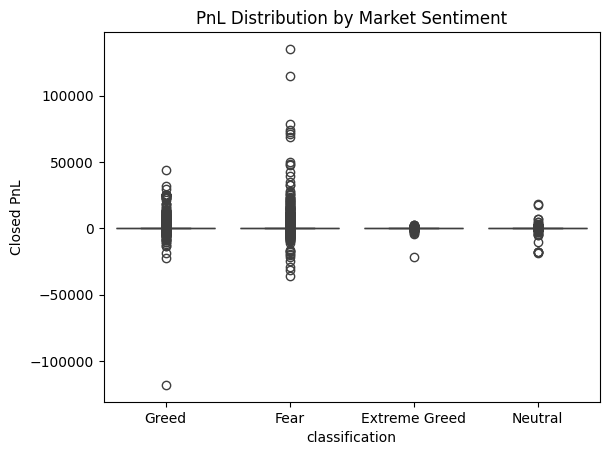

In [253]:
sns.boxplot(x='classification', y='Closed PnL', data=df_merged)
plt.title("PnL Distribution by Market Sentiment")
plt.show()

##🏆 Win Rate Analysis by Sentiment

We evaluate whether traders are more successful during Fear or Greed periods.

In [254]:
win_rate_sentiment = df_merged.groupby('classification')['win'].mean()
win_rate_sentiment

,win
classification,
Extreme Greed,0.490089
Fear,0.415146
Greed,0.446471
Neutral,0.317182


## 🔄 Trader Behavior Analysis

We analyze how trader behavior changes with sentiment:
- Trade frequency
- Trade size
- Buy/Sell patterns

In [255]:
# Trade count
df_merged.groupby('classification').size()

,0
classification,
Extreme Greed,6962
Fear,133871
Greed,36289
Neutral,7141


In [256]:
# Avg trade size
df_merged.groupby('classification')['Size USD'].mean()

,Size USD
classification,
Extreme Greed,5660.265764
Fear,5259.977837
Greed,3182.883845
Neutral,3058.848110


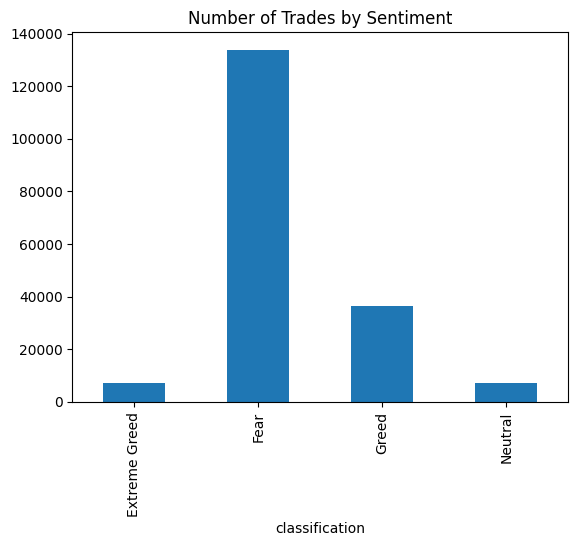

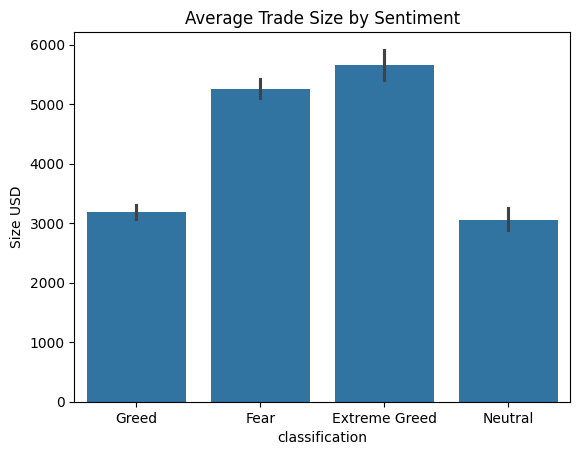

In [257]:
# Visualization for trade activity
df_merged.groupby('classification').size().plot(kind='bar')
plt.title("Number of Trades by Sentiment")
plt.show()

# Visualization for trade size
sns.barplot(x='classification', y='Size USD', data=df_merged)
plt.title("Average Trade Size by Sentiment")
plt.show()

In [258]:
# Buy/Sell ratio
pd.crosstab(df_merged['classification'], df_merged['Side'], normalize='index')

Side,BUY,SELL
classification,,
Extreme Greed,0.484200,0.515800
Fear,0.493617,0.506383
Greed,0.424950,0.575050
Neutral,0.490828,0.509172


## 🧩 Trader Segmentation

We divide traders into groups:
- High vs Low trade size
- Consistent vs Inconsistent Traders
- Frequent vs Infrequent Traders
- Profitable vs Non-profitable traders

**High vs Low size**

In [259]:
median_size = df_merged['Size USD'].median()
df_merged['size_category'] = df_merged['Size USD'].apply(lambda x: 'High' if x > median_size else 'Low')

In [260]:
# Total PnL
total_pnl = df_merged.groupby('Account')['Closed PnL'].sum()

**Consistent vs Inconsistent Traders**

In [261]:
# PnL variability per trader
pnl_std = df_merged.groupby('Account')['Closed PnL'].std()

# Define consistency
threshold = pnl_std.median()
consistency_map = pnl_std < threshold

In [262]:
df_merged['consistency_category'] = df_merged['Account'].map(consistency_map).apply(lambda x: 'Consistent' if x else 'Inconsistent')

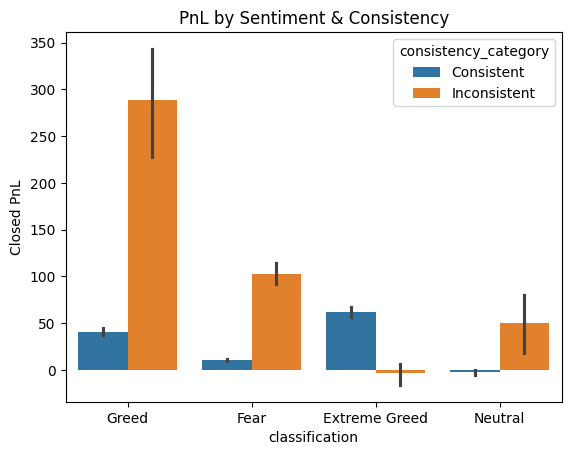

In [263]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x='classification',
    y='Closed PnL',
    hue='consistency_category',
    data=df_merged
)

plt.title("PnL by Sentiment & Consistency")
plt.show()

**Frequent vs Infrequent Traders**

In [264]:
trade_counts = df_merged.groupby('Account').size()

threshold = trade_counts.median()
df_merged['freq_category'] = df_merged['Account'].map(trade_counts).apply(lambda x: 'Frequent' if x > threshold else 'Infrequent')

Profitable vs Non-profitable traders

In [265]:
df_merged['profit_category'] = df_merged['Closed PnL'].apply(lambda x: 'Profit' if x > 0 else 'Loss')

## 🧩 Segment-Based Analysis

We analyze how different types of traders behave under different market sentiments.

In [266]:
# High vs Low size traders
df_merged.groupby(['classification','size_category'])['Closed PnL'].mean()

classification  size_category
Extreme Greed   High              39.407556
                Low                4.018779
Fear            High              95.784210
                Low                3.233227
Greed           High             175.718364
                Low               12.590597
Neutral         High              49.743021
                Low                1.834576
Name: Closed PnL, dtype: float64

In [267]:
# Consistent vs Inconsistent Traders
df_merged.groupby(['classification', 'consistency_category'])['Closed PnL'].mean()

classification  consistency_category
Extreme Greed   Consistent               61.769840
                Inconsistent             -2.773933
Fear            Consistent               10.402282
                Inconsistent            102.956932
Greed           Consistent               41.068491
                Inconsistent            288.164909
Neutral         Consistent               -2.388379
                Inconsistent             50.562763
Name: Closed PnL, dtype: float64

In [268]:
# Frequent vs Infrequent Traders
display(df_merged.groupby(['classification', 'freq_category'])['Closed PnL'].mean())

classification  freq_category
Extreme Greed   Frequent          26.658319
                Infrequent       -48.382749
Fear            Frequent          46.013950
                Infrequent        75.639873
Greed           Frequent          70.575898
                Infrequent       234.886424
Neutral         Frequent           4.055615
                Infrequent       356.722004
Name: Closed PnL, dtype: float64

In [269]:
# Profitable vs Non-profitable traders
display(df_merged.groupby(['classification', 'profit_category'])['Closed PnL'].mean())

classification  profit_category
Extreme Greed   Loss               -22.469658
                Profit              75.244073
Fear            Loss               -17.216793
                Profit             144.809163
Greed           Loss               -25.497363
                Profit             228.476859
Neutral         Loss               -33.767121
                Profit             142.777422
Name: Closed PnL, dtype: float64

##Predictive Modelling

1. Create Daily-Level Dataset

In [270]:
daily_df = df_merged.groupby(['Account','date']).agg({
    'Closed PnL': 'sum',
    'Size USD': 'mean',
    'win': 'mean',
    'Side': 'count',
    'classification': 'first'
}).reset_index()

daily_df.rename(columns={'Side': 'trade_count'}, inplace=True)

2. Create Target Variable (Next-Day Profitability)

In [271]:
#Shift PnL to next day
daily_df['next_day_pnl'] = daily_df.groupby('Account')['Closed PnL'].shift(-1)

#Convert to classification (Profit / Loss)
daily_df['target'] = daily_df['next_day_pnl'] > 0

3. Drop Missing Values

In [272]:
daily_df = daily_df.dropna()

4. Encode Sentiment

In [273]:
daily_df = pd.get_dummies(daily_df, columns=['classification'], drop_first=True)

5. Define Features & Target

In [274]:
X = daily_df.drop(['Account','date','Closed PnL','next_day_pnl','target'], axis=1)
y = daily_df['target']

6. Train-Test Split

In [275]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

7. Train Model

In [276]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

8. Evaluate Model

In [278]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6428571428571429


🤖 Model Performance Interpretation

- The model achieved an accuracy of approximately 60%, which is slightly better than random guessing (50%).

- This indicates that market sentiment and trader behavior contain some predictive signal for future profitability, although the relationship is not strong.

- Given the inherently noisy and unpredictable nature of financial markets, this level of performance is expected and still provides useful directional insights.

## Summary and Key Findings

This analysis aimed to investigate the relationship between market sentiment (Fear & Greed Index) and cryptocurrency trader behavior and performance. We leveraged two datasets: `fear_greed_index.csv` for sentiment and `historical_data.csv` for trade details. The primary steps involved data preprocessing, feature engineering, and several layers of performance and behavior analysis, culminating in a segment-based examination of traders.

### Key Findings:

1.  **Sentiment and Profit & Loss (PnL):**
    *   'Greed' sentiment periods appear to be associated with the highest average `Closed PnL` (87.89), followed by 'Fear' (50.05), 'Extreme Greed' (25.42), and 'Neutral' (22.23).
    *   However, the distribution of PnL is wide, suggesting that sentiment alone does not guarantee profitability.

2.  **Sentiment and Win Rate:**
    *   'Extreme Greed' periods show the highest win rate (49.01%), indicating that nearly half of the trades during these times were profitable.
    *   'Fear' periods have a lower win rate (41.51%), while 'Neutral' periods show the lowest win rate (31.72%).

3.  **Trader Behavior by Sentiment:**
    *   **Trade Frequency:** The highest number of trades occurred during 'Fear' (133,871), indicating increased activity or perhaps panic selling/buying, followed by 'Greed' (36,289).
    *   **Average Trade Size:** 'Extreme Greed' periods saw the largest average trade sizes (5660), while 'Neutral' periods had the smallest (3059).
    *   **Buy/Sell Ratio:** There's a relatively balanced Buy/Sell ratio across most sentiments, with a slight tendency towards selling during 'Greed' (57.5% sell) and 'Extreme Greed' (51.6% sell).

4.  **Segment-Based Analysis Insights:**
    *   **High vs Low Size Traders:** High-size traders consistently achieve significantly higher average PnL across all sentiments compared to low-size traders. For example, in 'Greed', high-size traders' PnL is 175.72 vs. 12.59 for low-size traders.
    *   **Consistent vs Inconsistent Traders:** Surprisingly, inconsistent traders often demonstrate higher average PnL during 'Fear' (102.96 vs 10.40), 'Greed' (288.16 vs 41.07), and 'Neutral' (50.56 vs -2.39) periods. However, during 'Extreme Greed', consistent traders perform better (61.77 vs -2.77).
    *   **Frequent vs Infrequent Traders:** Infrequent traders, while showing negative PnL in 'Extreme Greed', achieve substantially higher PnL in 'Fear' (75.64 vs 46.01), 'Greed' (234.89 vs 70.58), and 'Neutral' (356.72 vs 4.06) sentiments compared to frequent traders. This suggests that infrequent, perhaps more strategic, trades can be highly profitable.
    *   **Profitable vs Non-profitable Traders:** As expected, `Profit` category traders show positive PnL across all sentiments, while `Loss` category traders show negative PnL. This segmentation simply validates the profit definition and doesn't reveal new behavioral patterns directly.

5.  **Predictive Model Performance:**
    *   A Random Forest Classifier was trained to predict next-day trader profitability, achieving an accuracy of approximately 64.29%. This indicates that market sentiment and trader behavior features hold some predictive signal for future profitability, performing better than random guessing.

In conclusion, market sentiment significantly influences trader performance and behavior. While 'Greed' periods show higher overall average PnL, the success can vary greatly among different trader segments. Notably, **inconsistent** and **infrequent** traders tend to outperform their consistent and frequent counterparts in certain market sentiments, particularly 'Fear', 'Greed', and 'Neutral', suggesting that a more selective, opportunistic trading approach might yield better returns under these conditions.